# Synthetic Intent Dataset — Quality Evaluation

Đánh giá chất lượng `data/en/synthetic_intent.csv` trước khi đưa vào training.

**Input:** `data/en/synthetic_intent.csv` — output từ `synthesize_intent.py` (600 rows/class)  
**Output:** `data/en/intent_data.csv` — training-ready (500 rows/class, columns: `text`, `label`)  
**Reports:** `reports/en/synthetic_*.png` + `reports/en/synthetic_quality_report.md`

**Run from project root:** `jupyter notebook notebooks/en/eval_synthetic_intent.ipynb`

In [1]:
# !pip install datasketch  # uncomment if not installed
import os
import sys

# Ensure paths resolve from project root
if os.path.basename(os.getcwd()) in ("en", "notebooks"):
    os.chdir(os.path.join(os.getcwd(), "..", ".."))
print(f"Working directory: {os.getcwd()}")

Working directory: d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG


## Cell 1 — Load + Basic Stats

In [2]:
import pandas as pd

DATA_PATH = "data/en/synthetic_intent.csv"

df = pd.read_csv(DATA_PATH)

print(f"Total rows: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(f"\nClass distribution:")
print(df["intent_label"].value_counts().to_string())

for label in sorted(df["intent_label"].unique()):
    print(f"\n--- {label} (3 examples) ---")
    for q in df[df["intent_label"] == label]["question"].head(3):
        print(f"  {q}")

Total rows: 1800
Columns: ['question', 'intent_label']

Class distribution:
intent_label
BOTH                600
HEALTH_ADVICE       600
NUTRITION_LOOKUP    600

--- BOTH (3 examples) ---
  Is kiwi high in sodium and beneficial for gout?
  Can carrots help control diabetes because of its vitamin B12?
  For fatty liver disease management, how much quinoa can I eat given its vitamin C content?

--- HEALTH_ADVICE (3 examples) ---
  Can people with depression eat sweet potatoes?
  Which foods are beneficial for people with cardiovascular disease?
  Is eggs recommended or not recommended for rheumatoid arthritis?

--- NUTRITION_LOOKUP (3 examples) ---
  What percentage of daily zinc is in pumpkin seeds?
  How does the phosphorus in skim milk compare to the daily requirement?
  What is the nutritional value of quinoa in terms of iron?


## Cell 2 — Label Distribution

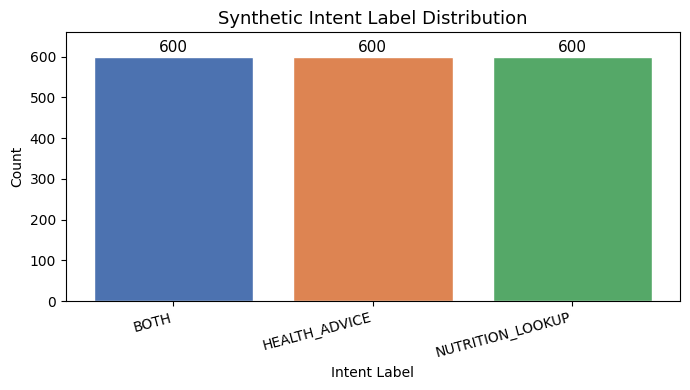

Saved → reports/en/synthetic_distribution.png
Class imbalance ratio: 1.00x  ✅ OK


In [3]:
import os
import matplotlib.pyplot as plt

os.makedirs("reports/en", exist_ok=True)

counts = df["intent_label"].value_counts().sort_index()
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor="white")

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(count), ha="center", va="bottom", fontsize=11)

ax.set_title("Synthetic Intent Label Distribution", fontsize=13)
ax.set_ylabel("Count")
ax.set_xlabel("Intent Label")
ax.set_ylim(0, counts.max() + 60)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("reports/en/synthetic_distribution.png", dpi=150)
plt.show()

print("Saved → reports/en/synthetic_distribution.png")
imbalance = counts.max() / counts.min()
print(f"Class imbalance ratio: {imbalance:.2f}x  {'✅ OK' if imbalance < 1.2 else '⚠️ Unbalanced'}")

## Cell 3 — Dedup with MinHash LSH (threshold=0.85)

Loại câu gần giống nhau (Jaccard similarity > 0.85 trên word ngrams).  
Sau dedup → save `data/en/intent_data.csv` (training-ready, 500/class, columns: `text`, `label`).

In [4]:
!pip install datasketch


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: D:\Data\File for Google Drive real\Project\Nutrition_RAG\.venv\Scripts\python.exe -m pip install --upgrade pip


In [5]:
from datasketch import MinHash, MinHashLSH

THRESHOLD = 0.85
NUM_PERM = 128


def make_minhash(text: str, num_perm: int = NUM_PERM) -> MinHash:
    m = MinHash(num_perm=num_perm)
    for token in text.lower().split():
        m.update(token.encode("utf8"))
    return m


lsh = MinHashLSH(threshold=THRESHOLD, num_perm=NUM_PERM)
keep_indices = []

for i, row in df.iterrows():
    m = make_minhash(row["question"])
    if not lsh.query(m):
        lsh.insert(str(i), m)
        keep_indices.append(i)

df_clean = df.loc[keep_indices].reset_index(drop=True)

removed = len(df) - len(df_clean)
print(f"Original:  {len(df)} rows")
print(f"Removed:   {removed} duplicates ({removed/len(df)*100:.1f}%)")
print(f"Remaining: {len(df_clean)} rows")
print(f"\nPer-class after dedup:")
print(df_clean["intent_label"].value_counts().to_string())

# Save training-ready CSV (500/class, rename columns for training notebook)
sampled_dfs = []
for label, group in df_clean.groupby("intent_label"):
    sampled_dfs.append(group.sample(min(500, len(group)), random_state=42))
df_train = pd.concat(sampled_dfs).reset_index(drop=True)
df_train = (
    df_train
    .rename(columns={"question": "text", "intent_label": "label"})
    [["text", "label"]]
)

df_train.to_csv("data/en/intent_data.csv", index=False)
print(f"\nSaved → data/en/intent_data.csv  ({len(df_train)} rows)")
print(df_train["label"].value_counts().to_string())

Original:  1800 rows
Removed:   91 duplicates (5.1%)
Remaining: 1709 rows

Per-class after dedup:
intent_label
BOTH                589
NUTRITION_LOOKUP    584
HEALTH_ADVICE       536

Saved → data/en/intent_data.csv  (1500 rows)
label
BOTH                500
HEALTH_ADVICE       500
NUTRITION_LOOKUP    500


## Cell 4 — Length Distribution

Histogram số token/câu per class. Lọc outlier < 5 hoặc > 30 tokens.

Outliers — too short (<5 tokens):  0
Outliers — too long  (>30 tokens): 0

Overall stats:
count    1709.0
mean       10.0
std         2.8
min         5.0
25%         8.0
50%        10.0
75%        12.0
max        19.0


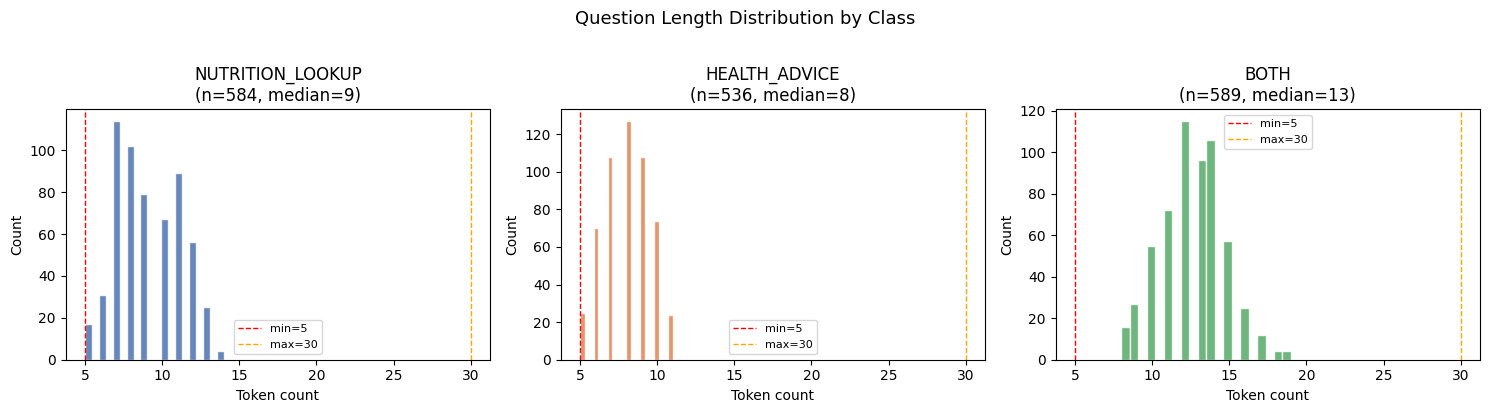

Saved → reports/en/synthetic_length.png


In [6]:
import matplotlib.pyplot as plt

df_clean["token_count"] = df_clean["question"].str.split().str.len()

short_mask = df_clean["token_count"] < 5
long_mask  = df_clean["token_count"] > 30
print(f"Outliers — too short (<5 tokens):  {short_mask.sum()}")
print(f"Outliers — too long  (>30 tokens): {long_mask.sum()}")
print(f"\nOverall stats:")
print(df_clean["token_count"].describe().round(1).to_string())

labels_order = ["NUTRITION_LOOKUP", "HEALTH_ADVICE", "BOTH"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
for ax, label, color in zip(axes, labels_order, colors):
    subset = df_clean[df_clean["intent_label"] == label]["token_count"]
    ax.hist(subset, bins=20, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(5,  color="red",    linestyle="--", linewidth=1, label="min=5")
    ax.axvline(30, color="orange", linestyle="--", linewidth=1, label="max=30")
    ax.set_title(f"{label}\n(n={len(subset)}, median={subset.median():.0f})")
    ax.set_xlabel("Token count")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Question Length Distribution by Class", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("reports/en/synthetic_length.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → reports/en/synthetic_length.png")

## Cell 5 — Inter-class Cosine Similarity

Encode tất cả câu với all-MiniLM-L6-v2, tính avg cosine within-class vs between-class.  
**Within > Between** → các class phân biệt rõ → dataset chất lượng tốt.

d:\Data\File for Google Drive real\Project\Nutrition_RAG\HEALTHCARE-RAG\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading sentence-transformers/all-MiniLM-L6-v2...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7808.22it/s]


  NUTRITION_LOOKUP: 200 embeddings encoded
  HEALTH_ADVICE: 200 embeddings encoded
  BOTH: 200 embeddings encoded


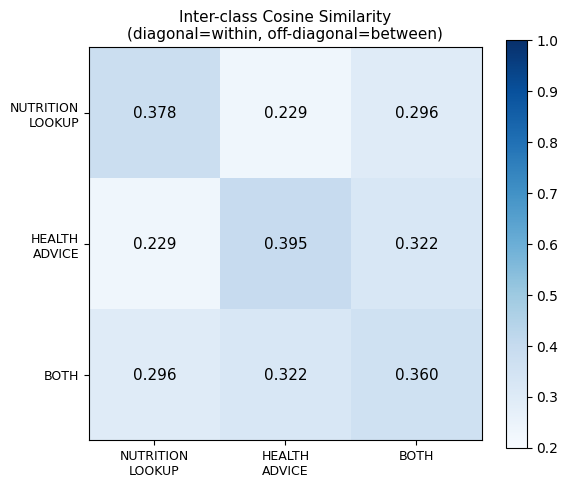

Saved → reports/en/synthetic_similarity_heatmap.png

Avg within-class similarity:  0.378
Avg between-class similarity: 0.283
Separation ratio: 1.34x
✅ Classes are well-separated

Saved → reports/en/synthetic_quality_report.md
# Synthetic Intent Dataset Quality Report

## Overview
- Raw generated: 1800 rows (600/class)
- After MinHash LSH dedup (threshold=0.85): 1709 rows
- Training set saved: 1500 rows (500/class)

## Label Distribution
label
BOTH                500
HEALTH_ADVICE       500
NUTRITION_LOOKUP    500

## Length Stats (tokens/question)
count    1709.0
mean       10.0
std         2.8
min         5.0
25%         8.0
50%        10.0
75%        12.0
max        19.0

## Similarity Analysis
- Avg within-class cosine:  0.378
- Avg between-class cosine: 0.283
- Separation ratio: 1.34x

## Conclusion
Dataset quality is acceptable. Classes are well-separated.



In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

EMBED_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
SAMPLE_PER_CLASS = 200  # cap to keep encoding fast

print(f"Loading {EMBED_MODEL}...")
embed_model = SentenceTransformer(EMBED_MODEL)

class_embs: dict[str, np.ndarray] = {}
for label in labels_order:
    texts = df_clean[df_clean["intent_label"] == label]["question"].tolist()
    if len(texts) > SAMPLE_PER_CLASS:
        texts = texts[:SAMPLE_PER_CLASS]
    embs = embed_model.encode(texts, show_progress_bar=False, normalize_embeddings=True)
    class_embs[label] = embs
    print(f"  {label}: {len(embs)} embeddings encoded")

# Average pairwise cosine (embeddings L2-normalized → dot product = cosine)
n = len(labels_order)
sim_matrix = np.zeros((n, n))
for i, li in enumerate(labels_order):
    for j, lj in enumerate(labels_order):
        sim_matrix[i, j] = float((class_embs[li] @ class_embs[lj].T).mean())

# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_matrix, vmin=0.2, vmax=1.0, cmap="Blues")
short_labels = ["NUTRITION\nLOOKUP", "HEALTH\nADVICE", "BOTH"]
ax.set_xticks(range(n)); ax.set_xticklabels(short_labels, fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(short_labels, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.3f}",
                ha="center", va="center", fontsize=11,
                color="white" if sim_matrix[i,j] > 0.7 else "black")
ax.set_title("Inter-class Cosine Similarity\n(diagonal=within, off-diagonal=between)", fontsize=11)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("reports/en/synthetic_similarity_heatmap.png", dpi=150)
plt.show()
print("Saved → reports/en/synthetic_similarity_heatmap.png")

within_avg  = np.mean([sim_matrix[i, i] for i in range(n)])
between_avg = np.mean([sim_matrix[i, j] for i in range(n) for j in range(n) if i != j])
ratio = within_avg / between_avg if between_avg > 0 else float("inf")

print(f"\nAvg within-class similarity:  {within_avg:.3f}")
print(f"Avg between-class similarity: {between_avg:.3f}")
print(f"Separation ratio: {ratio:.2f}x")
print(f"{'✅ Classes are well-separated' if within_avg > between_avg else '⚠️ Low separation — classes may overlap'}")

# Quality report
report = f"""# Synthetic Intent Dataset Quality Report

## Overview
- Raw generated: {len(df)} rows ({len(df)//3}/class)
- After MinHash LSH dedup (threshold={THRESHOLD}): {len(df_clean)} rows
- Training set saved: {len(df_train)} rows (500/class)

## Label Distribution
{df_train['label'].value_counts().to_string()}

## Length Stats (tokens/question)
{df_clean['token_count'].describe().round(1).to_string()}

## Similarity Analysis
- Avg within-class cosine:  {within_avg:.3f}
- Avg between-class cosine: {between_avg:.3f}
- Separation ratio: {ratio:.2f}x

## Conclusion
{'Dataset quality is acceptable. Classes are well-separated.' if within_avg > between_avg else 'Warning: low class separation. Consider regenerating with stricter prompts.'}
"""

with open("reports/en/synthetic_quality_report.md", "w", encoding="utf-8") as f:
    f.write(report)
print("\nSaved → reports/en/synthetic_quality_report.md")
print(report)